### **Modeling notebook**
LendingClub Default Prediction for DSS

**Objective:** Calibrated probability model for human-AI experiment

In [1]:
import os
import sys
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import (
    roc_auc_score, brier_score_loss, log_loss,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.base import clone
from scipy.stats import ttest_rel
from xgboost import XGBClassifier

# ── Paths ─────────────────────────────────────────────────────────────────────
ROOT      = Path.cwd().parents[1]          # capstone/
DATA_PROC = ROOT / "data" / "processed" / "loan_v1.csv"
ARTIFACTS = ROOT / "artifacts"
BUILD_DIR = ARTIFACTS / "build"
FIGS_DIR  = ROOT / "codes" / "visualizations"
BUILD_DIR.mkdir(parents=True, exist_ok=True)
FIGS_DIR.mkdir(parents=True, exist_ok=True)

sys.path.append(str(ROOT / "codes"))

from feature_config import FEATURES, NUM_COLS, CAT_COLS, TARGET

np.random.seed(42)
pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")

print("ROOT      :", ROOT)
print("BUILD_DIR :", BUILD_DIR)
print("FIGS_DIR  :", FIGS_DIR)

ROOT      : /Users/annaasatryan/Desktop/capstone
BUILD_DIR : /Users/annaasatryan/Desktop/capstone/artifacts/build
FIGS_DIR  : /Users/annaasatryan/Desktop/capstone/codes/visualizations


**Data loading**

In [2]:
df = pd.read_csv(DATA_PROC)
df['issue_d'] = pd.to_datetime(df['issue_d'], errors='coerce')

print("Shape:", df.shape)
print("Default rate:", round(df[TARGET].mean(), 4))
print("Date range:", df['issue_d'].min(), "→", df['issue_d'].max())
print("\nFeatures used:", FEATURES)

Shape: (1298960, 15)
Default rate: 0.2008
Date range: 2007-06-01 00:00:00 → 2018-12-01 00:00:00

Features used: ['loan_amnt', 'term', 'int_rate', 'dti', 'revol_util', 'home_ownership', 'purpose', 'log_annual_inc', 'credit_history_years']


**Temporal splits**

Split strategy:
  
- train  → chronological 70% of pre-2016  (model fitting)
  
- cal    → first half of remaining 30%    (calibration only)
  
- val    → second half of remaining 30%   (model selection)
  
- test   → post-2016                      (final reporting, used once)


Calibration is isolated from validation to prevent isotonic
regression from memorizing its fitting set (ECE → 0 artifact).
Model selection is done on val. Test is never used for selection.

In [3]:
train_full = df[df['issue_d'] < "2016-01-01"].copy()
test       = df[df['issue_d'] >= "2016-01-01"].copy()

cutoff_cal = train_full['issue_d'].quantile(0.70)
train      = train_full[train_full['issue_d'] < cutoff_cal].copy()
cal_val    = train_full[train_full['issue_d'] >= cutoff_cal].copy()

cutoff_val = cal_val['issue_d'].quantile(0.50)
cal        = cal_val[cal_val['issue_d'] < cutoff_val].copy()
val        = cal_val[cal_val['issue_d'] >= cutoff_val].copy()


y_train = train[TARGET]
y_cal   = cal[TARGET]
y_val   = val[TARGET]
y_test  = test[TARGET]

# Features ONLY for modeling
X_train = train[FEATURES].copy()
X_cal   = cal[FEATURES].copy()
X_val   = val[FEATURES].copy()
X_test  = test[FEATURES].copy()

# Keep case_id separately (for export only)
case_id_train = train['case_id'].copy()
case_id_cal   = cal['case_id'].copy()
case_id_val   = val['case_id'].copy()
case_id_test  = test['case_id'].copy()

print(f"Train : {train.shape[0]:>8,}  |  default rate: {y_train.mean():.4f}")
print(f"Cal   : {cal.shape[0]:>8,}  |  default rate: {y_cal.mean():.4f}")
print(f"Val   : {val.shape[0]:>8,}  |  default rate: {y_val.mean():.4f}")
print(f"Test  : {test.shape[0]:>8,}  |  default rate: {y_test.mean():.4f}")

Train :  554,109  |  default rate: 0.1765
Cal   :  126,135  |  default rate: 0.2031
Val   :  138,972  |  default rate: 0.1995
Test  :  479,744  |  default rate: 0.2288


**Outlier capping (train-derived)**

DTI has extreme outliers. Clip at 99.9th percentile of train.
Same threshold applied to all splits — no leakage.

In [4]:
dti_upper = X_train['dti'].quantile(0.999)
for X in [X_train, X_cal, X_val, X_test]:
    X['dti'] = X['dti'].clip(upper=dti_upper)

print(f"DTI clipped at {dti_upper:.2f} (99.9th percentile of train)")

DTI clipped at 39.53 (99.9th percentile of train)


**Preprocessing pipeline**

In [5]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler',  StandardScaler())
        ]), NUM_COLS),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot',  OneHotEncoder(
                drop='first',
                handle_unknown='ignore',
                sparse_output=False
            ))
        ]), CAT_COLS)
    ]
)

**Metric function**

ECE uses fixed equal-width bins.
10 bins chosen as standard bias–variance tradeoff for calibration estimation
Fixed bins ensure ECE is comparable across subgroups,
time periods, and models. Quantile bins shift with each
distribution making cross-subset comparison invalid.

In [6]:
def compute_ece(y_true, y_prob, n_bins=10):
    y_true = np.array(y_true)
    y_prob = np.array(y_prob)
    bins   = np.linspace(0, 1, n_bins + 1)
    ece    = 0.0
    for i in range(n_bins):
        if i < n_bins - 1:
            mask = (y_prob >= bins[i]) & (y_prob < bins[i + 1])
        else:
            mask = (y_prob >= bins[i]) & (y_prob <= bins[i + 1])
        if mask.sum() == 0:
            continue
        acc  = y_true[mask].mean()
        conf = y_prob[mask].mean()
        ece += (mask.sum() / len(y_true)) * abs(acc - conf)
    return ece


def evaluate(y_true, y_prob, label=""):
    return {
        'Model'  : label,
        'AUC'    : round(roc_auc_score(y_true, y_prob), 4),
        'Brier'  : round(brier_score_loss(y_true, y_prob), 4),
        'LogLoss': round(log_loss(y_true, y_prob), 4),
        'ECE'    : round(compute_ece(y_true, y_prob), 4),
    }

# Bootstrap uses fixed seed for reproducibility
def bootstrap_ci(y_true, y_prob, metric_fn, n=1000, alpha=0.05, seed=42):
    y_true = np.array(y_true)
    y_prob = np.array(y_prob)
    rng    = np.random.default_rng(seed)
    N      = len(y_true)
    vals   = []
    for _ in range(n):
        idx = rng.choice(N, N, replace=True)
        vals.append(metric_fn(y_true[idx], y_prob[idx]))
    lo = round(np.percentile(vals, 100 * alpha / 2), 4)
    hi = round(np.percentile(vals, 100 * (1 - alpha / 2)), 4)
    return lo, hi

**Model definitions**

- Three models: interpretable baseline (Logistic) + twogradient boosting variants (XGB, HGB).
- Hyperparameters are fixed (not grid-searched) 
- the goal is a defensible, calibrated DSS model, not maximizing AUC.

In [7]:
models = {
    'Logistic': Pipeline([
        ('preprocessor', preprocessor),
        ('model', LogisticRegression(
            C=0.1,
            max_iter=3000,
            random_state=42
        ))
    ]),
    'XGB': Pipeline([
        ('preprocessor', preprocessor),
        ('model', XGBClassifier(
            n_estimators=300,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            eval_metric='logloss',
            random_state=42,
            verbosity=0
        ))
    ]),
    'HGB': Pipeline([
        ('preprocessor', preprocessor),
        ('model', HistGradientBoostingClassifier(
            max_iter=300,
            max_depth=4,
            learning_rate=0.05,
            random_state=42
        ))
    ])
}

**Resampled training stability analysis**

In [8]:
N_RUNS = 10
rng = np.random.default_rng(42)

records = []

for run in range(N_RUNS):
    print(f"\n=== BOOTSTRAP RUN {run+1}/{N_RUNS} ===")

    # ----------------------------
    # 1. Bootstrap sample (TRAIN ONLY)
    # ----------------------------
    idx = rng.choice(len(X_train), len(X_train), replace=True)
    X_train_boot = X_train.iloc[idx]
    y_train_boot = y_train.iloc[idx]

    for name, base_pipe in models.items():

        # ensure fresh model
        pipe = clone(base_pipe)

        # ----------------------------
        # 2. Fit on bootstrapped data
        # ----------------------------
        pipe.fit(X_train_boot, y_train_boot)

        # ----------------------------
        # 3. Calibration
        # ----------------------------
        iso = CalibratedClassifierCV(pipe, method='isotonic', cv='prefit')
        sig = CalibratedClassifierCV(pipe, method='sigmoid', cv='prefit')

        iso.fit(X_cal, y_cal)
        sig.fit(X_cal, y_cal)

        # ----------------------------
        # 4. Select calibration (Brier)
        # ----------------------------
        probs_val_iso = iso.predict_proba(X_val)[:, 1]
        probs_val_sig = sig.predict_proba(X_val)[:, 1]

        brier_iso = brier_score_loss(y_val, probs_val_iso)
        brier_sig = brier_score_loss(y_val, probs_val_sig)

        if brier_iso <= brier_sig:
            chosen = iso
        else:
            chosen = sig

        # ----------------------------
        # 5. Evaluate on TEST
        # ----------------------------
        probs_test = chosen.predict_proba(X_test)[:, 1]

        auc = roc_auc_score(y_test, probs_test)
        brier = brier_score_loss(y_test, probs_test)
        ece = compute_ece(y_test, probs_test)

        records.append({
            'run': run,
            'model': name,
            'AUC': auc,
            'Brier': brier,
            'ECE': ece
        })

robust_df = pd.DataFrame(records)

print("\n=== ROBUSTNESS SUMMARY ===\n")

summary = robust_df.groupby('model')[['AUC','Brier','ECE']].agg(['mean','std'])
print(summary)


=== BOOTSTRAP RUN 1/10 ===

=== BOOTSTRAP RUN 2/10 ===

=== BOOTSTRAP RUN 3/10 ===

=== BOOTSTRAP RUN 4/10 ===

=== BOOTSTRAP RUN 5/10 ===

=== BOOTSTRAP RUN 6/10 ===

=== BOOTSTRAP RUN 7/10 ===

=== BOOTSTRAP RUN 8/10 ===

=== BOOTSTRAP RUN 9/10 ===

=== BOOTSTRAP RUN 10/10 ===

=== ROBUSTNESS SUMMARY ===

               AUC               Brier                 ECE          
              mean       std      mean       std      mean       std
model                                                               
HGB       0.696559  0.000279  0.162759  0.000107  0.032058  0.000788
Logistic  0.691372  0.000230  0.163925  0.000062  0.033053  0.000196
XGB       0.696819  0.000274  0.162878  0.000091  0.033861  0.000513


**Statistical comparison**

In [9]:
def paired_test(df, m1, m2, metric):
    x = df[df['model']==m1][metric].values
    y = df[df['model']==m2][metric].values
    
    stat, p = ttest_rel(x, y)
    diff = x - y
    
    print(f"\n{m1} vs {m2} ({metric})")
    print(f"Mean difference: {diff.mean():.6f}")
    print(f"Std difference : {diff.std():.6f}")
    print(f"t-stat: {stat:.4f}, p-value: {p:.6f}")

# Compare models
paired_test(robust_df, 'Logistic', 'HGB', 'Brier')
paired_test(robust_df, 'Logistic', 'XGB', 'Brier')
paired_test(robust_df, 'HGB', 'XGB', 'Brier')


Logistic vs HGB (Brier)
Mean difference: 0.001166
Std difference : 0.000075
t-stat: 46.3687, p-value: 0.000000

Logistic vs XGB (Brier)
Mean difference: 0.001047
Std difference : 0.000088
t-stat: 35.8279, p-value: 0.000000

HGB vs XGB (Brier)
Mean difference: -0.000119
Std difference : 0.000076
t-stat: -4.7191, p-value: 0.001091


Model comparison across logistic regression, XGBoost, and histogram gradient boosting showed minimal differences in predictive performance. Bootstrap analysis confirmed high stability across training resamples, with Brier score differences between models on the order of 0.001. While these differences are statistically significant due to large sample size, they are practically negligible. 

**Train + calibrate all models**

Pipeline:
  1. Fit base model on X_train
  2. Fit isotonic and sigmoid calibration on X_cal (cv='prefit')
  3. Select calibration method using VAL BRIER within each model class. 
  4. Store val Brier for model selection (NOT test)
  5. Store test probabilities for final reporting only


In [10]:
X_train_model = X_train.copy()
X_cal_model   = X_cal.copy()
X_val_model   = X_val.copy()
X_test_model  = X_test.copy()

trained = {}

for name, base_pipe in models.items():
    print(f"\nTraining {name}...")

    # ensure fresh model
    pipe = clone(base_pipe)

    # 1. Fit base model
    pipe.fit(X_train_model, y_train)

    # 2. Calibration models
    iso = CalibratedClassifierCV(pipe, method='isotonic', cv='prefit')
    sig = CalibratedClassifierCV(pipe, method='sigmoid', cv='prefit')

    iso.fit(X_cal_model, y_cal)
    sig.fit(X_cal_model, y_cal)

    # 3. Predictions on validation
    probs_val_iso = iso.predict_proba(X_val_model)[:, 1]
    probs_val_sig = sig.predict_proba(X_val_model)[:, 1]

    # 4. Select calibration via BRIER
    brier_iso_val = brier_score_loss(y_val, probs_val_iso)
    brier_sig_val = brier_score_loss(y_val, probs_val_sig)

    if abs(brier_iso_val - brier_sig_val) < 1e-6:
        chosen = sig
        method = 'sigmoid'
        probs_val = probs_val_sig
    elif brier_iso_val < brier_sig_val:
        chosen = iso
        method = 'isotonic'
        probs_val = probs_val_iso
    else:
        chosen = sig
        method = 'sigmoid'
        probs_val = probs_val_sig

    # diagnostics
    ece_iso_val = compute_ece(y_val, probs_val_iso)
    ece_sig_val = compute_ece(y_val, probs_val_sig)

    # 5. Test predictions
    probs_test = chosen.predict_proba(X_test_model)[:, 1]

    val_brier = brier_score_loss(y_val, probs_val)

    trained[name] = {
        'model': chosen,
        'probs_val': probs_val,
        'probs_test': probs_test,
        'val_brier': round(val_brier, 4),
        'cal_method': method
    }

    print(f"  Calibration : {method}")
    print(f"  Val Brier   : iso={brier_iso_val:.4f} sig={brier_sig_val:.4f}")
    print(f"  Val ECE     : iso={ece_iso_val:.4f} sig={ece_sig_val:.4f}")

print("\nAll models trained and calibrated.")


Training Logistic...
  Calibration : isotonic
  Val Brier   : iso=0.1419 sig=0.1420
  Val ECE     : iso=0.0080 sig=0.0123

Training XGB...
  Calibration : isotonic
  Val Brier   : iso=0.1413 sig=0.1423
  Val ECE     : iso=0.0105 sig=0.0284

Training HGB...
  Calibration : sigmoid
  Val Brier   : iso=0.1412 sig=0.1411
  Val ECE     : iso=0.0086 sig=0.0085

All models trained and calibrated.


**Model selection**

Validation Brier is computed for all three models for comparison.
Logistic regression is **fixed** as the final model based on:

- Negligible performance differences (~0.001 Brier, ~0.006 AUC across 10 bootstrap resamples)
- High training stability (low variance confirmed by robustness analysis)
- Interpretability: coefficients are directly readable as log-odds
- Experimental clarity: a transparent model avoids confounding between model complexity and participant behavior in the DSS study

Test-set metrics reported below are **final reporting diagnostics only** — they are not used for model selection. Selection was performed on val Brier exclusively.

In [11]:
val_briers = {name: d['val_brier'] for name, d in trained.items()}

print("=== VALIDATION BRIER (model comparison) ===\n")
for name, b in val_briers.items():
    print(f"  {name}: {b:.4f}")

# FIXED FINAL MODEL
FINAL_MODEL_NAME = 'Logistic'
final_model      = trained['Logistic']['model']
final_probs      = trained['Logistic']['probs_test']

print(f"\nSelected: {FINAL_MODEL_NAME} (fixed for interpretability & equivalence)")

# # Prepare output for DSS / case selection
# test_output = X_test.copy()  # includes case_id
# test_output['y_true'] = y_test.values
# test_output['pred_prob'] = final_probs

=== VALIDATION BRIER (model comparison) ===

  Logistic: 0.1419
  XGB: 0.1413
  HGB: 0.1411

Selected: Logistic (fixed for interpretability & equivalence)


**Feature importance**

=== LOGISTIC REGRESSION COEFFICIENTS ===

                   feature  coefficient
            term_60 months     0.604922
   home_ownership_MORTGAGE    -0.531648
    purpose_small_business     0.527611
                  int_rate     0.441987
        home_ownership_OWN    -0.419191
       home_ownership_RENT    -0.278563
            log_annual_inc    -0.189749
           purpose_medical     0.184769
  purpose_home_improvement     0.163031
            purpose_moving     0.157153
                       dti     0.141294
purpose_debt_consolidation     0.121528
                 loan_amnt     0.074156
       home_ownership_NONE    -0.073928
             purpose_other     0.055939
       purpose_credit_card     0.053597
    purpose_major_purchase     0.049495
             purpose_house    -0.048972
          purpose_vacation     0.023197
      home_ownership_OTHER    -0.016785
      credit_history_years    -0.014121
                revol_util     0.004081


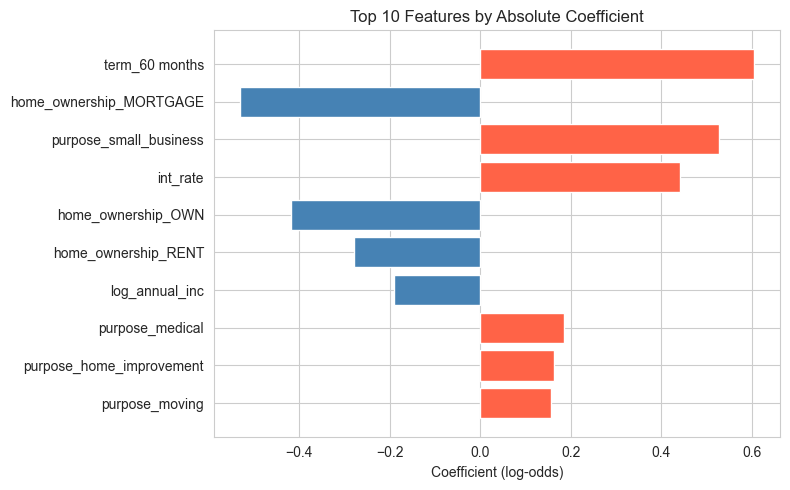

In [12]:
final_pipe = trained['Logistic']['model']

base_pipe           = final_pipe.calibrated_classifiers_[0].estimator
preprocessor_fitted = base_pipe.named_steps['preprocessor']
lr_model            = base_pipe.named_steps['model']

num_names  = NUM_COLS
cat_encoder = preprocessor_fitted.named_transformers_['cat'].named_steps['onehot']
cat_names   = list(cat_encoder.get_feature_names_out(CAT_COLS))
all_names   = num_names + cat_names

coef_df = pd.DataFrame({
    'feature':     all_names,
    'coefficient': lr_model.coef_[0]
}).sort_values('coefficient', key=abs, ascending=False)

print("=== LOGISTIC REGRESSION COEFFICIENTS ===\n")
print(coef_df.to_string(index=False))

coef_df.to_csv(BUILD_DIR / "lr_coefficients.csv", index=False)

fig, ax = plt.subplots(figsize=(8, 5))
top    = coef_df.head(10)
colors = ['tomato' if c > 0 else 'steelblue' for c in top['coefficient']]
ax.barh(range(len(top)), top['coefficient'].values, color=colors)
ax.set_yticks(range(len(top)))
ax.set_yticklabels(top['feature'].values)
ax.set_xlabel("Coefficient (log-odds)")
ax.set_title("Top 10 Features by Absolute Coefficient")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(FIGS_DIR / "feature_importance.png", dpi=150, bbox_inches='tight')
plt.show()

**Model comparison table**

In [13]:
results = []

for name, d in trained.items():
    m = evaluate(y_test, d['probs_test'], label=name)

    m['Calibration'] = d['cal_method']
    m['Val_Brier']   = d['val_brier']

    # Bootstrap confidence intervals
    auc_lo, auc_hi = bootstrap_ci(
        y_test.values,
        d['probs_test'],
        roc_auc_score
    )

    brier_lo, brier_hi = bootstrap_ci(
        y_test.values,
        d['probs_test'],
        brier_score_loss
    )

    m['AUC_95CI']   = f"[{auc_lo}, {auc_hi}]"
    m['Brier_95CI'] = f"[{brier_lo}, {brier_hi}]"

    results.append(m)

results_df = pd.DataFrame(results).set_index('Model')

print("\n=== MODEL COMPARISON — TEST SET (FINAL REPORTING) ===\n")
print(
    results_df[
        ['AUC','Brier','LogLoss','ECE',
         'Calibration','Val_Brier',
         'AUC_95CI','Brier_95CI']
    ].to_string()
)

# Effect sizes
delta_hgb = results_df.loc['Logistic','Brier'] - results_df.loc['HGB','Brier']
delta_xgb = results_df.loc['Logistic','Brier'] - results_df.loc['XGB','Brier']

print("\n=== EFFECT SIZE (Brier differences) ===")
print(f"Logistic - HGB: {delta_hgb:.6f}")
print(f"Logistic - XGB: {delta_xgb:.6f}")

print(f"\nFinal model: {FINAL_MODEL_NAME}")
print("Test metrics:")
print(evaluate(y_test, final_probs, label=FINAL_MODEL_NAME))


=== MODEL COMPARISON — TEST SET (FINAL REPORTING) ===

             AUC   Brier  LogLoss     ECE Calibration  Val_Brier          AUC_95CI        Brier_95CI
Model                                                                                               
Logistic  0.6914  0.1639   0.5132  0.0328    isotonic     0.1419  [0.6897, 0.6931]  [0.1632, 0.1646]
XGB       0.6973  0.1628   0.5002  0.0342    isotonic     0.1413  [0.6955, 0.6989]  [0.1621, 0.1636]
HGB       0.6968  0.1627   0.4978  0.0315     sigmoid     0.1411  [0.6951, 0.6985]   [0.162, 0.1634]

=== EFFECT SIZE (Brier differences) ===
Logistic - HGB: 0.001200
Logistic - XGB: 0.001100

Final model: Logistic
Test metrics:
{'Model': 'Logistic', 'AUC': np.float64(0.6914), 'Brier': np.float64(0.1639), 'LogLoss': 0.5132, 'ECE': np.float64(0.0328)}


Logistic regression was fixed as the final model for interpretability and experimental clarity. Bootstrap analysis across 10 resamples confirmed that Brier score differences between models are on the order of 0.001 — practically negligible at this scale. A transparent model minimizes confounds between model behavior and participant decision-making in the DSS experiment.

Test-set metrics in the table above are **final reporting diagnostics**. They were computed once, after model selection was complete on the validation set, and were not used to select or tune any model.

**Calibration curves**

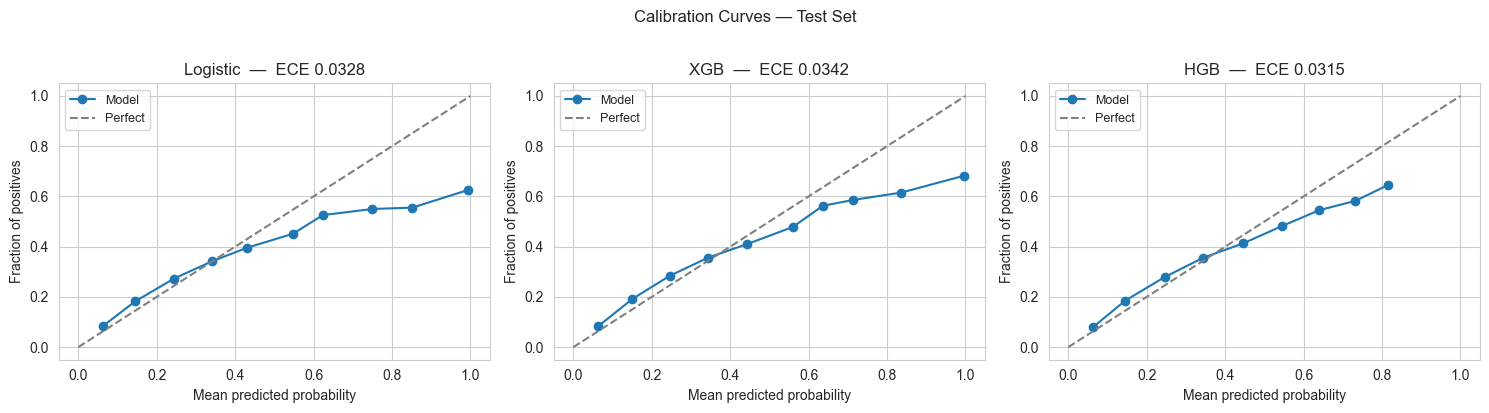

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, d) in zip(axes, trained.items()):
    prob_true, prob_pred = calibration_curve(y_test, d['probs_test'], n_bins=10)
    ece = compute_ece(y_test.values, d['probs_test'])
    ax.plot(prob_pred, prob_true, marker='o', label='Model')
    ax.plot([0, 1], [0, 1], '--', color='gray', label='Perfect')
    ax.set_title(f"{name}  —  ECE {ece:.4f}")
    ax.set_xlabel("Mean predicted probability")
    ax.set_ylabel("Fraction of positives")
    ax.legend(fontsize=9)

plt.suptitle("Calibration Curves — Test Set", y=1.02)
plt.tight_layout()
plt.savefig(FIGS_DIR / "calibration_curves.png", dpi=150, bbox_inches='tight')
plt.show()

**ECE by difficulty tier**

In [15]:
test_with_diff = test[['case_id', 'difficulty_tier']].copy()
test_with_diff['pred_prob'] = final_probs
test_with_diff['y_true'] = y_test.values

print("=== ECE BY DIFFICULTY TIER ===\n")
for tier in ['easy', 'medium', 'hard']:
    mask = test_with_diff['difficulty_tier'] == tier
    sub_y = test_with_diff.loc[mask, 'y_true'].values
    sub_p = test_with_diff.loc[mask, 'pred_prob'].values
    ece = compute_ece(sub_y, sub_p)
    brier = brier_score_loss(sub_y, sub_p)
    print(f"{tier:8s}: ECE={ece:.4f}, Brier={brier:.4f}, n={mask.sum():,}")

=== ECE BY DIFFICULTY TIER ===

easy    : ECE=0.0248, Brier=0.1155, n=241,081
medium  : ECE=0.0399, Brier=0.2032, n=175,439
hard    : ECE=0.0496, Brier=0.2391, n=63,224


**Probability distribution**

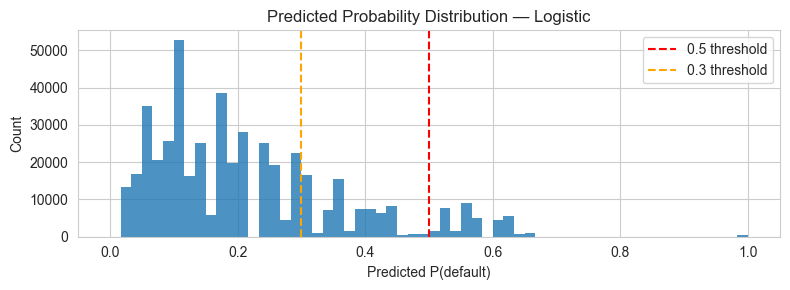

=== PROBABILITY DISTRIBUTION DIAGNOSTICS ===

Sharpness (variance)     : 0.0224
Mean predicted P(default): 0.2151
Actual default rate      : 0.2288
Calibration gap (mean)   : 0.0137

Fraction predicted > 0.5 : 0.0783
Fraction predicted > 0.3 : 0.2307
Fraction predicted > 0.2 : 0.4377

Prediction range distribution:
  0–0.1:  111,402  (23.2%)
  0.1–0.2:  158,317  (33.0%)
  0.2–0.3:   99,331  (20.7%)
  0.3–0.4:   49,041  (10.2%)
  0.4–0.5:   24,095  (5.0%)
  0.5–0.6:   24,975  (5.2%)
  0.6+:   12,565  (2.6%)


In [16]:
probs_arr = np.array(final_probs)

plt.figure(figsize=(8, 3))
plt.hist(probs_arr, bins=60, edgecolor='none', alpha=0.8)
plt.axvline(0.5, color='red',    linestyle='--', label='0.5 threshold')
plt.axvline(0.3, color='orange', linestyle='--', label='0.3 threshold')
plt.title(f"Predicted Probability Distribution — {FINAL_MODEL_NAME}")
plt.xlabel("Predicted P(default)")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.savefig(FIGS_DIR / "prob_distribution.png", dpi=150, bbox_inches='tight')
plt.show()

print("=== PROBABILITY DISTRIBUTION DIAGNOSTICS ===\n")
print(f"Sharpness (variance)     : {np.var(probs_arr):.4f}")
print(f"Mean predicted P(default): {probs_arr.mean():.4f}")
print(f"Actual default rate      : {y_test.mean():.4f}")
print(f"Calibration gap (mean)   : {abs(probs_arr.mean() - y_test.mean()):.4f}")
print(f"\nFraction predicted > 0.5 : {(probs_arr > 0.5).mean():.4f}")
print(f"Fraction predicted > 0.3 : {(probs_arr > 0.3).mean():.4f}")
print(f"Fraction predicted > 0.2 : {(probs_arr > 0.2).mean():.4f}")

print(f"\nPrediction range distribution:")
bins_diag   = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 1.0]
labels_diag = ['0–0.1','0.1–0.2','0.2–0.3','0.3–0.4','0.4–0.5','0.5–0.6','0.6+']
counts = (pd.cut(probs_arr, bins=bins_diag, labels=labels_diag)
            .value_counts()
            .sort_index())
for label, count in counts.items():
    print(f"  {label}: {count:>8,}  ({count/len(probs_arr)*100:.1f}%)")

**Interpretation: Probability Compression**

The model produces low-variance probabilities concentrated in [0.1–0.3].
This results in a low-signal decision environment, where cases are not trivially separable. Such conditions are desirable for studying human–AI interaction, as they increase reliance on probabilistic reasoning and amplify the role of interaction structure in decision-making. 

**Feature distribution shift**

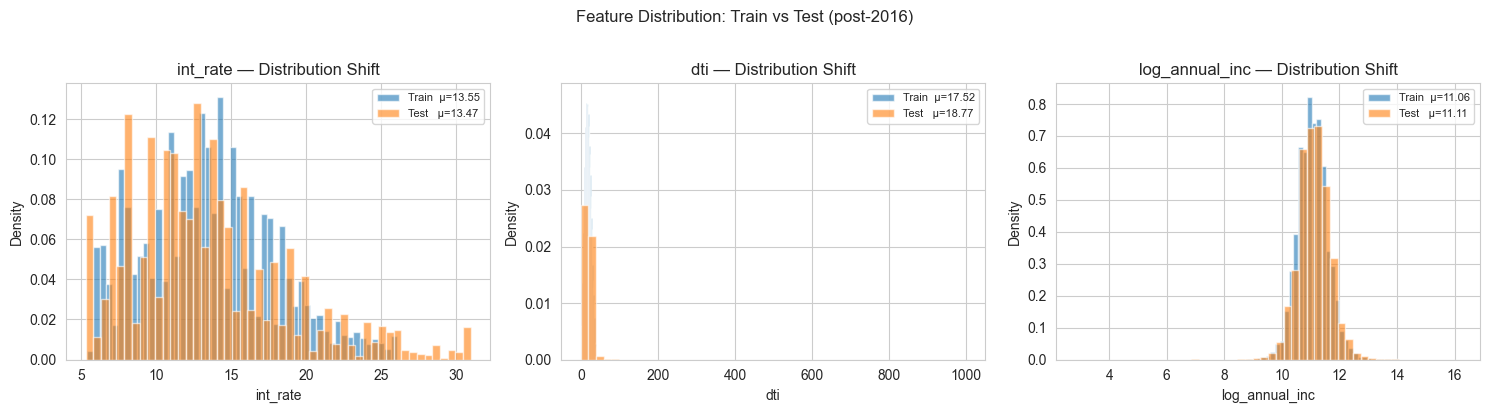

=== FEATURE DISTRIBUTION SHIFT ===

int_rate              train μ=13.548  test μ=13.467  Δ=-0.081
dti                   train μ=17.524  test μ=18.766  Δ=+1.242
log_annual_inc        train μ=11.058  test μ=11.115  Δ=+0.056


In [17]:
shift_features = ['int_rate', 'dti', 'log_annual_inc']
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, shift_features):
    ax.hist(train[col].dropna(), bins=50, alpha=0.6, density=True,
            label=f'Train  μ={train[col].mean():.2f}')
    ax.hist(test[col].dropna(),  bins=50, alpha=0.6, density=True,
            label=f'Test   μ={test[col].mean():.2f}')
    ax.set_title(f"{col} — Distribution Shift")
    ax.set_xlabel(col)
    ax.set_ylabel("Density")
    ax.legend(fontsize=8)

plt.suptitle("Feature Distribution: Train vs Test (post-2016)", y=1.02)
plt.tight_layout()
plt.savefig(FIGS_DIR / "feature_shift.png", dpi=150, bbox_inches='tight')
plt.show()

print("=== FEATURE DISTRIBUTION SHIFT ===\n")
for col in shift_features:
    delta = test[col].mean() - train[col].mean()
    print(f"{col:20s}  train μ={train[col].mean():.3f}  test μ={test[col].mean():.3f}  Δ={delta:+.3f}")

A moderate distribution shift is observed in debt-to-income ratio (Δ ≈ +1.24), indicating mild covariate shift between training and test periods. This further motivates the use of calibrated probabilities rather than threshold-based decisions.

**Export candidate pool (`artifacts/build/candidate_pool_scored.parquet`)**

In [18]:
FEATURES_ORDER = list(X_test.columns)

candidate_pool = X_test.copy()
candidate_pool['case_id']       = case_id_test.values
candidate_pool['y_true']        = y_test.values
candidate_pool['pred_prob']     = final_probs

candidate_pool = candidate_pool.merge(
    test[['case_id', 'difficulty_score', 'difficulty_tier']],
    on='case_id',
    how='left'
)

candidate_pool = candidate_pool[[
    'case_id',
    *FEATURES_ORDER,
    'y_true',
    'pred_prob',
    'difficulty_score',
    'difficulty_tier'
]]

# Deterministic sort
candidate_pool = candidate_pool.sort_values('case_id').reset_index(drop=True)

# ── Validation ────────────────────────────────────────────────────────────────
required_cols = ['case_id', 'y_true', 'pred_prob', 'difficulty_score', 'difficulty_tier']
missing_cols  = [c for c in required_cols if c not in candidate_pool.columns]
assert not missing_cols, f"Missing required columns: {missing_cols}"

assert candidate_pool['case_id'].is_unique, \
    f"Duplicate case_id values: {candidate_pool['case_id'].duplicated().sum()}"

assert candidate_pool['pred_prob'].between(0, 1).all(), \
    (f"pred_prob out of [0,1]: "
     f"min={candidate_pool['pred_prob'].min():.4f}, "
     f"max={candidate_pool['pred_prob'].max():.4f}")

assert not candidate_pool['difficulty_score'].isna().any(), \
    f"Missing difficulty_score: {candidate_pool['difficulty_score'].isna().sum()}"

assert not candidate_pool['difficulty_tier'].isna().any(), \
    f"Missing difficulty_tier: {candidate_pool['difficulty_tier'].isna().sum()}"

print("✓ All validation checks passed")

out_path = BUILD_DIR / "candidate_pool_scored.parquet"
candidate_pool.to_parquet(out_path, index=False)
print("Saved:", out_path)
print(f"Shape: {candidate_pool.shape}")

✓ All validation checks passed
Saved: /Users/annaasatryan/Desktop/capstone/artifacts/build/candidate_pool_scored.parquet
Shape: (479744, 14)


In [19]:
h = pd.read_parquet(BUILD_DIR / "candidate_pool_scored.parquet")
print("Shape   :", h.shape)
print("Columns :", list(h.columns))
print()
print(h.head())
print()
print("difficulty_tier counts:")
print(h['difficulty_tier'].value_counts().sort_index())

Shape   : (479744, 14)
Columns : ['case_id', 'loan_amnt', 'term', 'int_rate', 'dti', 'revol_util', 'home_ownership', 'purpose', 'log_annual_inc', 'credit_history_years', 'y_true', 'pred_prob', 'difficulty_score', 'difficulty_tier']

   case_id  loan_amnt       term  int_rate    dti  revol_util home_ownership  \
0   819216       1000  36 months      6.49   7.73        20.7       MORTGAGE   
1   819217       1000  36 months      6.49  17.59        68.1       MORTGAGE   
2   819218       1000  36 months      6.49  24.65        34.1            OWN   
3   819219       1000  36 months      6.99  17.34        15.2       MORTGAGE   
4   819220       1000  36 months      6.99  18.72        19.8            OWN   

            purpose  log_annual_inc  credit_history_years  y_true  pred_prob  \
0          vacation       11.034906             11.835729       0   0.033281   
1       credit_card       11.289794             17.998631       0   0.041643   
2    major_purchase       11.561725           